# CornerScout · 03 Secuencias SCR-15

**Responsabilidad única:** construir y auditar la etiqueta
`shot_within_15s` desde los eventos normalizados de 02.

La ventana es inclusiva en 15 segundos y termina por el primer límite:
tiempo, cambio del equipo en posesión, final del periodo o nuevo córner. Los
demás reinicios se auditan. Nunca se inspeccionan eventos posteriores al cierre.

## 0 · Entorno y contrato de entrada

In [1]:
import importlib.util
import subprocess
import sys

PACKAGES = {
    "numpy": "numpy>=1.26,<3",
    "pandas": "pandas>=2.2,<4",
    "matplotlib": "matplotlib>=3.8,<4",
    "pyarrow": "pyarrow>=16",
    "httpx": "httpx>=0.28,<1",
    "tqdm": "tqdm>=4.66",
}
missing = [spec for module, spec in PACKAGES.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Dependencias:", "instaladas las ausentes" if missing else "ya disponibles")

Dependencias: ya disponibles


In [2]:
import hashlib
import io
import json
import os
import platform
import zipfile
from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.auto import tqdm

try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

DATA_DIR = Path(os.environ.get(
    "CORNERSCOUT_DATA_DIR",
    "/content/drive/MyDrive/Corner_Scout/data" if IN_COLAB else "data",
))
CLEAN_DIR = DATA_DIR / "interim" / "02_clean"
CLEAN_EVENTS_DIR = CLEAN_DIR / "events"
OUT = DATA_DIR / "interim" / "03_scr15"
FIG_DIR = OUT / "figures"
for path in (OUT, FIG_DIR):
    path.mkdir(parents=True, exist_ok=True)

RULE_VERSION = "scr15-research-v1.2-first-limit"
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
ENVIRONMENT = {name: version(name) for name in
               ["numpy", "pandas", "matplotlib", "pyarrow", "tqdm"]}

contract_02_path = CLEAN_DIR / "contract.json"
assert contract_02_path.is_file(), "Ejecuta primero 02_limpieza_eda.ipynb"
contract_02 = json.loads(contract_02_path.read_text(encoding="utf-8"))
assert contract_02["contract_version"] == "02-clean-v2"
matches = pd.read_parquet(CLEAN_DIR / "matches_clean.parquet")
matches["match_date"] = pd.to_datetime(matches.match_date).dt.normalize()
expected_paths = [CLEAN_EVENTS_DIR / f"{int(mid)}.parquet" for mid in matches.match_id]
assert len(matches) == 380 and all(path.is_file() for path in expected_paths)
display(pd.Series({"entrada": str(CLEAN_DIR), "salida": str(OUT),
                   "regla": RULE_VERSION, "run_id": RUN_ID,
                   "python": platform.python_version(), **ENVIRONMENT}))

Mounted at /content/drive


,0
entrada,/content/drive/MyDrive/Corner_Scout/data/inter...
salida,/content/drive/MyDrive/Corner_Scout/data/inter...
regla,scr15-research-v1.2-first-limit
run_id,20260923T040749_884438Z
python,3.13.15
numpy,2.1.3
pandas,2.2.3
matplotlib,3.10.0
pyarrow,23.0.1
tqdm,4.67.3


## 1 · Motor de primer límite

La validación del reloj ocurre dentro del mismo recorrido que determina el
cierre. Esto impide invalidar una secuencia por anomalías que aparecen después
de 15 segundos, de un cambio de posesión o de un nuevo córner.

In [3]:
RESTARTS = {"Corner", "Free Kick", "Throw-in", "Goal Kick", "Kick Off", "Penalty"}
LIST_COLUMNS = ["starting_xi_ids", "related_event_ids"]


def validated_records(mid):
    path = CLEAN_EVENTS_DIR / f"{int(mid)}.parquet"
    frame = pd.read_parquet(path)
    for column in LIST_COLUMNS:
        if column in frame:
            frame[column] = frame[column].map(
                lambda value: json.loads(value) if isinstance(value, str) else value
            )
    records = frame.to_dict("records")
    ids = [event["event_id"] for event in records]
    indices = [event["index"] for event in records]
    assert ids and len(ids) == len(set(ids)) and len(indices) == len(set(indices))
    return sorted(records, key=lambda event: (event["period"], event["index"]))


def scan_window(records, start, seconds_limit=15):
    corner = records[start]
    result = dict(
        valid_sequence=True, end_reason=None, end_seconds=corner["seconds"],
        terminal_event_id=None, terminal_index=None,
        shot_ids=[], shot_times=[], shot_xgs=[], restart_ids=[],
        possession_change_ids=[], followup_cross_ids=[], first_recipient=corner["recipient"],
    )
    if (not np.isfinite(corner["seconds"]) or not corner["team"]
            or corner["possession_team"] != corner["team"]):
        result.update(valid_sequence=False, end_reason="invalid_start")
        return result

    previous_time = corner["seconds"]
    previous_possession = corner["possession"]
    for event in records[start + 1:]:
        if event["period"] != corner["period"]:
            result.update(end_reason="period_end", terminal_event_id=event["event_id"],
                          terminal_index=event["index"])
            break
        current_time = event["seconds"]
        if not np.isfinite(current_time):
            result.update(valid_sequence=False, end_reason="ambiguous_clock",
                          terminal_event_id=event["event_id"], terminal_index=event["index"])
            break
        elapsed = current_time - corner["seconds"]
        if elapsed > seconds_limit:
            result.update(end_reason="time_limit", end_seconds=corner["seconds"] + seconds_limit,
                          terminal_event_id=event["event_id"], terminal_index=event["index"])
            break
        if current_time < previous_time or elapsed < 0:
            result.update(valid_sequence=False, end_reason="ambiguous_clock",
                          terminal_event_id=event["event_id"], terminal_index=event["index"])
            break
        previous_time = current_time
        result["end_seconds"] = current_time
        if event["type"] == "Half End":
            result.update(end_reason="period_end", terminal_event_id=event["event_id"],
                          terminal_index=event["index"])
            break
        if not event["possession_team"]:
            result.update(valid_sequence=False, end_reason="unknown_possession",
                          terminal_event_id=event["event_id"], terminal_index=event["index"])
            break
        if event["possession_team"] != corner["team"]:
            result.update(end_reason="possession_team_change",
                          terminal_event_id=event["event_id"], terminal_index=event["index"])
            break
        if event["type"] == "Pass" and event["pass_type"] == "Corner":
            result["restart_ids"].append(event["event_id"])
            result.update(end_reason="new_corner", terminal_event_id=event["event_id"],
                          terminal_index=event["index"])
            break

        if event["possession"] != previous_possession:
            result["possession_change_ids"].append(event["event_id"])
        previous_possession = event["possession"]
        if event["pass_type"] in RESTARTS:
            result["restart_ids"].append(event["event_id"])
        if event["team"] == corner["team"] and event["type"] == "Pass" and event["cross"] is True:
            result["followup_cross_ids"].append(event["event_id"])
        if event["team"] == corner["team"] and event["type"] == "Shot":
            result["shot_ids"].append(event["event_id"])
            result["shot_times"].append(elapsed)
            result["shot_xgs"].append(event["xg"])
    else:
        result.update(valid_sequence=False, end_reason="unobserved_end")
    return result


def label_sequence(result):
    valid = result["valid_sequence"]
    xgs = result["shot_xgs"]
    complete_xg = valid and all(np.isfinite(value) and 0 <= value <= 1 for value in xgs)
    return dict(
        shot_within_15s=int(bool(result["shot_ids"])) if valid else np.nan,
        n_shots=len(result["shot_ids"]) if valid else np.nan,
        seconds_to_first_shot=min(result["shot_times"]) if valid and result["shot_times"] else np.nan,
        xg_complete=complete_xg,
        xg_sequence=float(sum(xgs)) if complete_xg else np.nan,
    )


def extract_corners(records, mid, seconds_limit=15):
    rows = []
    for index, corner in enumerate(records):
        if corner["type"] != "Pass" or corner["pass_type"] != "Corner":
            continue
        result = scan_window(records, index, seconds_limit)
        rows.append({**corner, **result, **label_sequence(result), "match_id": int(mid),
                     "rule_version": RULE_VERSION, "window_seconds": seconds_limit})
    return rows

## 2 · Pruebas de límites con datos sintéticos

Estas pruebas verifican la regla, no representan resultados de fútbol. Incluyen
regresiones posteriores a cada cierre para demostrar que no se vuelven a mirar.

In [4]:
def toy_event(index, seconds, kind="Pass", team="A", possession=1, period=1, **changes):
    event = dict(event_id=f"toy-{index}", index=index, period=period, minute=0., second=0.,
        seconds=float(seconds), type=kind, team=team, possession_team=team,
        possession=possession, player="Prueba", player_id=1, recipient=None,
        pass_type=None, height=None, pass_technique=None, pass_outcome=None,
        shot_outcome=None, card=None, cross=False, x=120., y=0., end_x=110., end_y=40.,
        xg=.1, goals_for_before=0, goals_against_before=0, score_diff=0,
        game_state="drawing", match_minute=0., match_phase="00-30",
        is_stoppage_time=False, attacking_players=11, defending_players=11,
        player_difference=0, numerical_state="equal",
        seconds_since_previous_same_team_corner=np.nan, repeat_corner_60s=False,
        context_version="test", starting_xi_ids=[], related_event_ids=[])
    event.update(changes)
    return event


corner = toy_event(1, 100, pass_type="Corner")
cases = [
    ("tiro exacto a 15", [corner, toy_event(2, 115, "Shot"), toy_event(3, 116)], 1, True),
    ("tiro posterior", [corner, toy_event(2, 115.001, "Shot")], 0, True),
    ("pérdida no reabre", [corner, toy_event(2, 103, team="B"), toy_event(3, 110, "Shot")], 0, True),
    ("nuevo ID mismo equipo", [corner, toy_event(2, 104, possession=2),
                               toy_event(3, 110, "Shot", possession=2), toy_event(4, 116)], 1, True),
    ("otro periodo", [corner, toy_event(2, 102, "Shot", period=2)], 0, True),
    ("retroceso dentro", [corner, toy_event(2, 108), toy_event(3, 106)], None, False),
    ("retroceso tras tiempo", [corner, toy_event(2, 116), toy_event(3, 112, "Shot")], 0, True),
    ("retroceso tras posesión", [corner, toy_event(2, 104, team="B"), toy_event(3, 102)], 0, True),
    ("retroceso tras nuevo córner", [corner, toy_event(2, 108, pass_type="Corner"), toy_event(3, 106)], 0, True),
    ("nuevo córner cierra", [corner, toy_event(2, 108, pass_type="Corner"), toy_event(3, 110, "Shot")], 0, True),
    ("tiro sin xG", [corner, toy_event(2, 110, "Shot", xg=np.nan), toy_event(3, 116)], 1, True),
]
test_rows = []
for description, events, expected, expected_valid in cases:
    found = extract_corners(events, -1)[0]
    target_ok = pd.isna(found["shot_within_15s"]) if expected is None else found["shot_within_15s"] == expected
    assert target_ok and found["valid_sequence"] == expected_valid, description
    test_rows.append({"caso": description, "target": found["shot_within_15s"],
                      "válida": found["valid_sequence"], "cierre": found["end_reason"]})
assert not extract_corners(cases[-1][1], -1)[0]["xg_complete"]
display(pd.DataFrame(test_rows))

,caso,target,válida,cierre
0,tiro exacto a 15,1.0,True,time_limit
1,tiro posterior,0.0,True,time_limit
2,pérdida no reabre,0.0,True,possession_team_change
3,nuevo ID mismo equipo,1.0,True,time_limit
4,otro periodo,0.0,True,period_end
5,retroceso dentro,NaN,False,ambiguous_clock
6,retroceso tras tiempo,0.0,True,time_limit
7,retroceso tras posesión,0.0,True,possession_team_change
8,retroceso tras nuevo córner,0.0,True,new_corner
9,nuevo córner cierra,0.0,True,new_corner


## 3 · Construcción completa

In [5]:
corner_rows, audit_rows, manifest_rows, errors = [], [], [], []
for match in tqdm(matches.itertuples(index=False), total=len(matches), desc="Construir SCR-15"):
    try:
        records = validated_records(match.match_id)
        extracted = extract_corners(records, match.match_id)
        corner_rows.extend(extracted)
        audit_rows.append({"match_id": int(match.match_id), "events": len(records),
                           "corners": len(extracted),
                           "excluded": sum(not row["valid_sequence"] for row in extracted)})
        path = CLEAN_EVENTS_DIR / f"{int(match.match_id)}.parquet"
        manifest_rows.append({"file": path.name, "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
                              "rows": len(records)})
    except (AssertionError, ValueError, KeyError, OSError) as exc:
        errors.append({"match_id": int(match.match_id), "error": str(exc)})

display(pd.DataFrame(errors, columns=["match_id", "error"]))
assert not errors, "SCR-15 no publica resultados parciales"
corners = pd.DataFrame(corner_rows).merge(matches, on="match_id", validate="many_to_one")
corners["opponent"] = np.where(corners.team.eq(corners.home_team), corners.away_team, corners.home_team)
quality = pd.DataFrame(audit_rows)
assert corners.event_id.is_unique and len(corners) == 3841
assert corners.valid_sequence.sum() == 3835
assert (~corners.valid_sequence).sum() == 6
print(f"{len(quality)} partidos · {quality.events.sum():,} eventos · {len(corners):,} córners")
print(f"Evaluables: {corners.valid_sequence.sum():,} · no evaluables: {(~corners.valid_sequence).sum()}")
display(corners.end_reason.value_counts().rename("n"))

Construir SCR-15:   0%|          | 0/380 [00:00<?, ?it/s]

,match_id,error


380 partidos · 1,295,354 eventos · 3,841 córners
Evaluables: 3,835 · no evaluables: 6


,n
end_reason,
time_limit,2864
possession_team_change,904
period_end,38
new_corner,29
ambiguous_clock,6


## 4 · Atribución y reinicios

Cada tiro puede pertenecer como máximo a un córner. Un nuevo córner cierra la
secuencia anterior y comienza otra; saques de banda y tiros libres continúan
como evidencia auditada.

In [6]:
shot_links = corners[["event_id", "match_id", "shot_ids"]].explode("shot_ids").dropna(subset=["shot_ids"])
shared_shots = shot_links.loc[shot_links.shot_ids.duplicated(keep=False)].sort_values("shot_ids")
assert shared_shots.empty

restart_links = (corners[["event_id", "match_id", "team", "seconds", "shot_ids", "restart_ids"]]
                 .explode("restart_ids").dropna(subset=["restart_ids"])
                 .rename(columns={"event_id": "corner_id", "team": "corner_team",
                                  "seconds": "corner_seconds", "restart_ids": "restart_event_id"}))
restart_details = []
for mid in restart_links.match_id.unique():
    event_map = {event["event_id"]: event for event in validated_records(int(mid))}
    for link in restart_links.loc[restart_links.match_id.eq(mid)].itertuples(index=False):
        event = event_map[link.restart_event_id]
        restart_details.append({"match_id": int(mid), "corner_id": link.corner_id,
            "restart_event_id": link.restart_event_id,
            "restart_type": event.get("pass_type") or event.get("type"),
            "restart_team": event.get("team"), "same_team": event.get("team") == link.corner_team,
            "elapsed_seconds": event.get("seconds") - link.corner_seconds,
            "policy": "closes_previous_sequence" if event.get("pass_type") == "Corner"
                      else "audit_only_no_automatic_close"})
restart_audit = pd.DataFrame(restart_details)
print("Tiros compartidos:", len(shared_shots), "· reinicios auditados:", len(restart_audit))
display(restart_audit.groupby(["restart_type", "same_team", "policy"], dropna=False).size().rename("n").reset_index())

Tiros compartidos: 0 · reinicios auditados: 105


,restart_type,same_team,policy,n
0,Corner,True,closes_previous_sequence,29
1,Free Kick,True,audit_only_no_automatic_close,1
2,Throw-in,True,audit_only_no_automatic_close,75


## 5 · Conciliación de las exclusiones

La implementación anterior de investigación excluía cinco secuencias por una
regresión observada después de que ya habían cerrado a los 15 segundos. La tabla
siguiente conserva la comparación por evento cuando el ZIP original está
disponible. La demo se compara por separado y no se modifica.

In [7]:
comparison_rows = []
current = corners.set_index("event_id")

demo_path = DATA_DIR / "processed" / "corners.parquet"
if demo_path.is_file():
    demo = pd.read_parquet(demo_path).set_index("event_id")
    for event_id in sorted(set(current.index) & set(demo.index)):
        if bool(current.at[event_id, "valid_sequence"]) != bool(demo.at[event_id, "valid_sequence"]):
            comparison_rows.append({"event_id": event_id, "comparison": "demo",
                                    "previous_valid": bool(demo.at[event_id, "valid_sequence"]),
                                    "current_valid": bool(current.at[event_id, "valid_sequence"]),
                                    "classification": "implementation_difference"})

archives = sorted(
    (DATA_DIR / "interim").glob("03_scr15-*.zip")
)
if archives:
    with zipfile.ZipFile(archives[-1]) as archive:
        old = pd.read_parquet(io.BytesIO(archive.read("03_scr15/corners_scr15.parquet"))).set_index("event_id")
    for event_id in sorted(set(current.index) & set(old.index)):
        old_valid = bool(old.at[event_id, "valid_sequence"])
        new_valid = bool(current.at[event_id, "valid_sequence"])
        if old_valid != new_valid or not new_valid:
            comparison_rows.append({"event_id": event_id, "comparison": "research_v1.1",
                "previous_valid": old_valid, "current_valid": new_valid,
                "classification": "post_close_regression_old_scan" if not old_valid and new_valid
                                  else "in_window_clock_regression" if not old_valid and not new_valid
                                  else "other"})

reconciliation = pd.DataFrame(comparison_rows, columns=["event_id", "comparison",
    "previous_valid", "current_valid", "classification"])
if archives:
    research = reconciliation.loc[reconciliation.comparison.eq("research_v1.1")]
    assert (research.classification == "post_close_regression_old_scan").sum() == 5
    assert (research.classification == "in_window_clock_regression").sum() == 6
display(reconciliation.groupby(["comparison", "classification"], dropna=False).size().rename("n").reset_index())
display(reconciliation)
if reconciliation.empty:
    reconciliation_status = "not_available"

    print(
        "Conciliación histórica no ejecutada: "
        "no se encontró la demo ni el ZIP de investigación."
    )
else:
    reconciliation_status = "completed"

    display(
        reconciliation.groupby(
            ["comparison", "classification"],
            dropna=False
        ).size().rename("n").reset_index()
    )

    display(reconciliation)

print("Estado de conciliación:", reconciliation_status)

,comparison,classification,n


,event_id,comparison,previous_valid,current_valid,classification


Conciliación histórica no ejecutada: no se encontró la demo ni el ZIP de investigación.
Estado de conciliación: not_available


## 6 · Resultados y ejemplos auditables

,match_id,event_id,team,period,index,seconds,end_reason,terminal_event_id,terminal_index
29,3825563,5099b6d4-ee48-49e5-aa33-5d55eb7e8dd0,Atlético Madrid,1.0,2007.0,2750.808,ambiguous_clock,4cb0d6ab-aa1e-4048-aab4-c176460cbae0,2020.0
1107,3825661,a2e323f1-eedb-472c-80b3-400fee483c09,Real Madrid,1.0,1904.0,2762.734,ambiguous_clock,bfa07397-e7ba-4fbd-9243-46ed18cf6d61,1905.0
1266,3825673,312b028e-6c4c-4133-b1d2-238b76072cf2,RC Deportivo La Coruña,1.0,1622.0,2688.444,ambiguous_clock,16100d57-30b3-4127-a357-5d6f9f237cc3,1635.0
1526,3825699,421eb603-4962-4240-ab51-e7609d9e0fb6,Sevilla,1.0,1350.0,2756.404,ambiguous_clock,b27a21c1-f5f3-4779-a4e3-226f42e437f5,1351.0
3791,3825869,5c91ad0d-1cb6-4f9e-8077-cf7c0e061c6a,Athletic Club,1.0,1797.0,2852.790,ambiguous_clock,9c0c986c-4618-47d1-8b69-2202bb65682c,1798.0
3814,3825908,bed39f58-7361-45dc-9fd1-3676555c56ed,Eibar,1.0,1553.0,2753.238,ambiguous_clock,7e382348-0927-442c-a7f1-464329515dab,1559.0


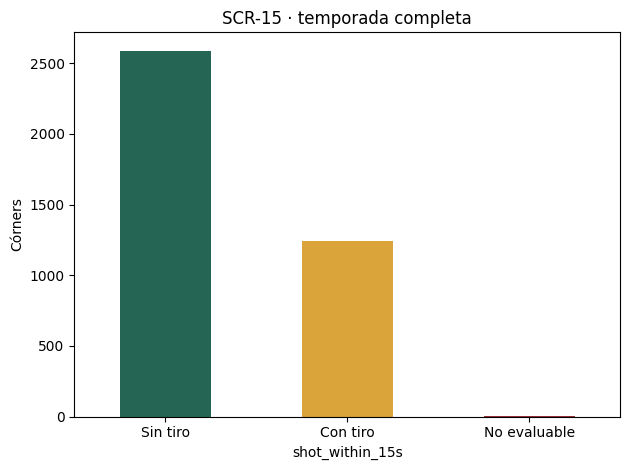

SCR-15 evaluable: 0.3246414602346806


In [8]:
excluded = corners.loc[~corners.valid_sequence,
    ["match_id", "event_id", "team", "period", "index", "seconds",
     "end_reason", "terminal_event_id", "terminal_index"]]
display(excluded)

target_counts = corners.shot_within_15s.map({0.: "Sin tiro", 1.: "Con tiro"}).fillna("No evaluable").value_counts()
target_counts.plot.bar(rot=0, color=["#246653", "#dba43b", "#9b3030"])
plt.title("SCR-15 · temporada completa"); plt.ylabel("Córners")
plt.tight_layout(); plt.savefig(FIG_DIR / "01_etiqueta_y_exclusiones.png", dpi=140, bbox_inches="tight")
plt.show(); plt.close()
print("SCR-15 evaluable:", corners.loc[corners.valid_sequence, "shot_within_15s"].mean())

## 7 · Contrato de salida

In [9]:
def sha256_file(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()


def export_table(frame, filename):
    result = frame.copy()
    for column in result:
        if result[column].map(lambda value: isinstance(value, (list, dict))).any():
            result[column] = result[column].map(
                lambda value: json.dumps(value, ensure_ascii=False)
                if isinstance(value, (list, dict)) else value
            )
    path = OUT / filename
    result.to_parquet(path, index=False)
    return {"file": filename, "rows": len(result), "columns": len(result.columns),
            "sha256": sha256_file(path)}


exports = [
    export_table(corners, "corners_scr15.parquet"),
    export_table(quality, "scr15_quality_report.parquet"),
    export_table(restart_audit, "restart_audit.parquet"),
    export_table(shared_shots, "shared_shots_audit.parquet"),
    export_table(reconciliation, "scr15_reconciliation.parquet"),
    export_table(excluded, "excluded_sequences.parquet"),
]
input_manifest = pd.DataFrame(manifest_rows)
input_manifest.to_csv(OUT / "input_manifest.csv", index=False)

contract = {
    "stage": "03_scr15", "contract_version": "03-scr15-v2",
    "run_id": RUN_ID, "rule_version": RULE_VERSION, "window_seconds": 15,
    "source_contract_version": contract_02["contract_version"],
    "source_event_manifest_sha256": contract_02["event_manifest_sha256"],
    "input_manifest_sha256": sha256_file(OUT / "input_manifest.csv"),
    "counts": {"matches": 380, "events": int(quality.events.sum()),
               "corners": int(len(corners)), "evaluable": int(corners.valid_sequence.sum()),
               "excluded": int((~corners.valid_sequence).sum()),
               "with_shot": int(corners.shot_within_15s.sum()),
               "shared_shots": int(shared_shots.shot_ids.nunique()) if len(shared_shots) else 0,
               "new_corner_closures": int(corners.end_reason.eq("new_corner").sum()),
               "restarts_audited": int(len(restart_audit))},
    "synthetic_tests_passed": len(test_rows), "exports": exports,
    "environment": ENVIRONMENT, "python": platform.python_version(),
}
(OUT / "contract.json").write_text(
    json.dumps(contract, ensure_ascii=False, indent=2), encoding="utf-8"
)
display(pd.Series(contract["counts"]))
print("Contrato:", OUT / "contract.json")

,0
matches,380
events,1295354
corners,3841
evaluable,3835
excluded,6
with_shot,1245
shared_shots,0
new_corner_closures,29
restarts_audited,105


Contrato: /content/drive/MyDrive/Corner_Scout/data/interim/03_scr15/contract.json


### Conclusión

La regla de primer límite produce **3,835 córners evaluables** y seis secuencias
desconocidas por anomalías de reloj dentro de su ventana. Cinco exclusiones de
la versión 1.1 vuelven a ser negativas evaluables porque la regresión ocurrió
después del cierre. Ningún tiro se atribuye a dos córners.